In [2]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
import numpy as np

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


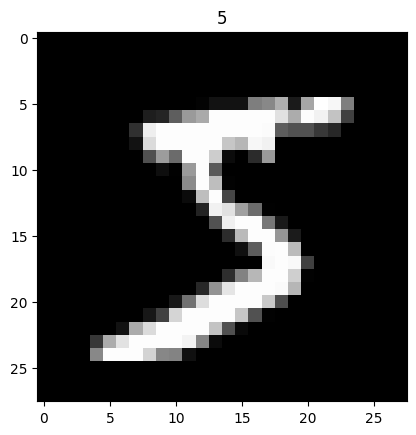

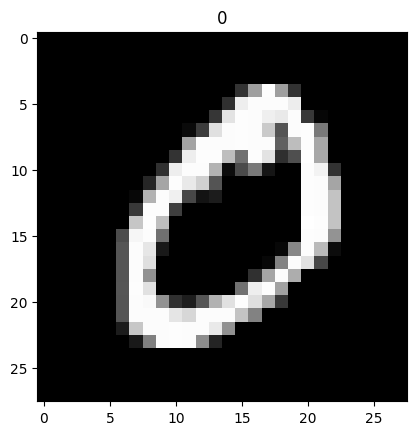

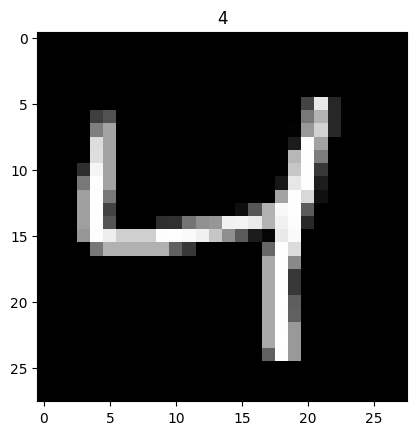

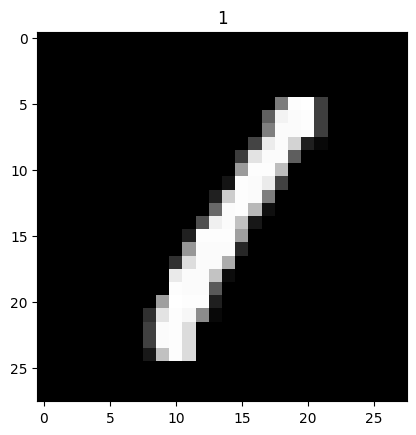

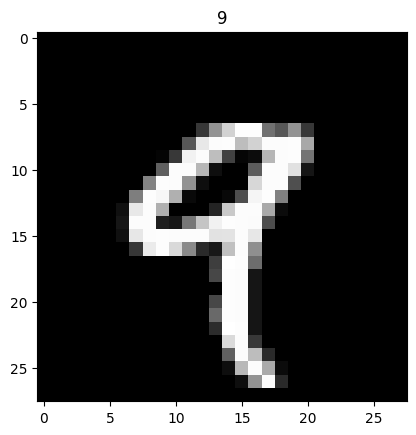

In [4]:
for i in range(5):
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.show()

{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


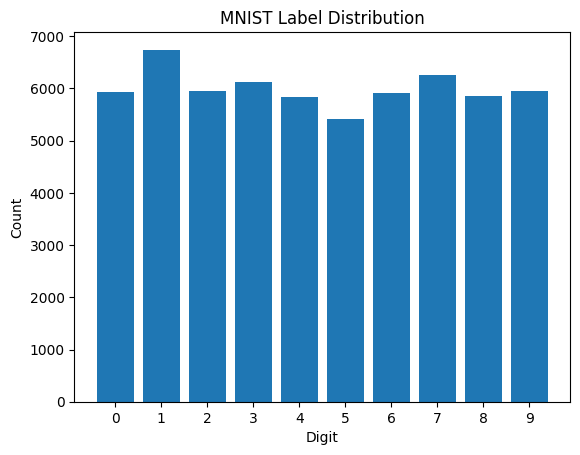

In [6]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))
plt.bar(unique, counts)
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("MNIST Label Distribution")
plt.xticks(unique)
plt.show()

## Problem Definition

Let the dataset be a subset of the MNIST dataset restricted to two classes: digits **0** and **1**. We define the training dataset as:

$$
\mathcal{D} = {(x^{(i)}, y^{(i)})}_{i=1}^{N}
$$

where:

* $x^{(i)} \in \mathbb{R}^{28 \times 28}$ represents the $i$-th grayscale image
* After flattening: $x^{(i)} \in \mathbb{R}^{784}$
* $y^{(i)} \in {0,1}$ is the corresponding label

---

The objective is to learn a function:

$$
f_\theta : \mathbb{R}^{784} \rightarrow {0,1}
$$

parameterized by $\theta$, that maps an input image to its correct class.

---

In probabilistic form, we model:

$$
P(y = 1 \mid x; \theta)
$$

and define the prediction as:

$$
\hat{y} =
\begin{cases}
1 & \text{if } P(y = 1 \mid x; \theta) \geq 0.5 \
0 & \text{otherwise}
\end{cases}
$$

---

The learning objective is to find optimal parameters $\theta^*$ that minimize a loss function over the dataset:

$$
\theta^* = \arg\min_{\theta} \frac{1}{N} \sum_{i=1}^{N} \mathcal{L}(f_\theta(x^{(i)}), y^{(i)})
$$

---

For example, using binary cross-entropy loss:

$$
\mathcal{L}(y, \hat{y}) = - \left[ y \log(\hat{y}) + (1 - y)\log(1 - \hat{y}) \right]
$$

---

Thus, the problem is formulated as a **supervised binary classification task** in a high-dimensional feature space $\mathbb{R}^{784}$, where the goal is to learn a decision boundary that separates the two classes (digits 0 and 1).


# Data Processing

In [7]:
# load official MNIST split
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

# keep only digits 0 and 1 in TRAIN
train_mask = (y_train_full == 0) | (y_train_full == 1)
X_train_full = X_train_full[train_mask]
y_train_full = y_train_full[train_mask]

# keep only digits 0 and 1 in TEST
test_mask = (y_test == 0) | (y_test == 1)
X_test = X_test[test_mask]
y_test = y_test[test_mask]

print("Filtered training set:", X_train_full.shape, y_train_full.shape)
print("Filtered test set:", X_test.shape, y_test.shape)

# normalize pixels to [0, 1]
X_train_full = X_train_full.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# flatten images
X_train_full = X_train_full.reshape(X_train_full.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# split only TRAIN into train + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=42,
    stratify=y_train_full
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

# standardize using TRAIN statistics only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std

Filtered training set: (12665, 28, 28) (12665,)
Filtered test set: (2115, 28, 28) (2115,)
Train shape: (10765, 784) (10765,)
Validation shape: (1900, 784) (1900,)
Test shape: (2115, 784) (2115,)


# Model Implemntation

## 1) Logistic Regression

In [ ]:
# Create model
import logistic_regression as lr
log_reg = lr.LogisticRegression(learning_rate=0.01, epochs=500)


# Train
log_reg.fit(X_train, y_train)

# Evaluate
lr_val_acc=log_reg.accuracy(X_val, y_val)
print("Train Accuracy:", log_reg.accuracy(X_train, y_train))
print("Validation Accuracy:", lr_val_acc)

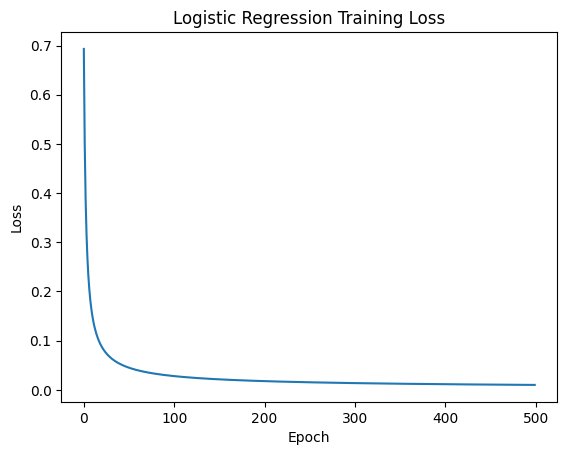

In [ ]:

plt.plot(log_reg.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Logistic Regression Training Loss")
plt.show()

[[ 978    2]
 [   0 1135]]


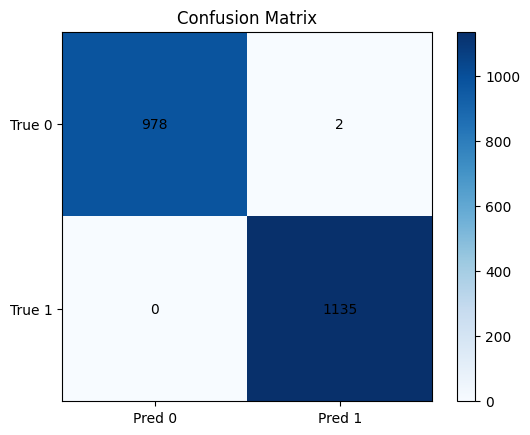

In [ ]:
def confusion_matrix_binary(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp],
                     [fn, tp]])

y_pred_test = log_reg.predict(X_test)
cm = confusion_matrix_binary(y_test, y_pred_test)

print(cm)

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.show()

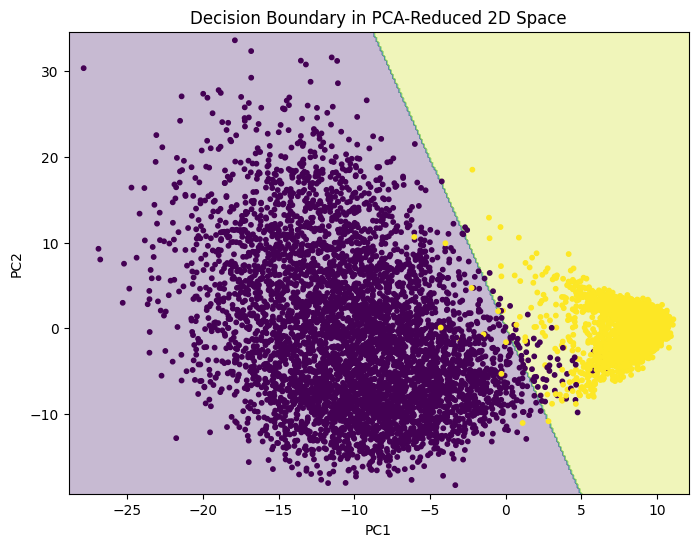

In [ ]:
from sklearn.decomposition import PCA

# reduce to 2D
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

# train a new model only on 2D projected data
log_reg_2d = lr.LogisticRegression(learning_rate=0.01, epochs=500)
log_reg_2d.fit(X_train_2d, y_train)

# mesh grid
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = log_reg_2d.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Decision Boundary in PCA-Reduced 2D Space")
plt.show()

## 📌 Overview

In this project, we implemented **Logistic Regression from scratch using NumPy** to classify handwritten digits from the MNIST dataset.  
The task was simplified to a **binary classification problem** by selecting only digits:

- **0 → class 0**
- **1 → class 1**

Each image is:
- Originally: `28 × 28`
- Flattened into: `784-dimensional vector`

So the model learns a function:

\[
f(x) = \sigma(w^T x + b)
\]

where:
- \( w \in \mathbb{R}^{784} \)
- \( b \in \mathbb{R} \)
- \( \sigma(z) = \frac{1}{1 + e^{-z}} \) is the sigmoid function

---

## ⚙️ Model Implementation

We implemented Logistic Regression manually without using ML libraries.

### Key components:

### 1. Sigmoid Function
Maps outputs to probabilities:

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

---

### 2. Loss Function (Binary Cross-Entropy)

\[
\mathcal{L}(y, \hat{y}) = - \left[ y \log(\hat{y}) + (1 - y)\log(1 - \hat{y}) \right]
\]

This loss penalizes:
- wrong confident predictions heavily
- correct predictions lightly

---

### 3. Gradient Descent

We update parameters using:

\[
dw = \frac{1}{m} X^T (\hat{y} - y)
\]

\[
db = \frac{1}{m} \sum (\hat{y} - y)
\]

This moves the model toward minimizing the loss.

---

## 📉 Training Behavior (Loss Curve)

During training, we track the loss at each epoch.

### Observation:
- Loss decreases smoothly over time
- No oscillations or divergence

### Interpretation:
- Gradient descent is working correctly
- Learning rate is appropriate
- Model is converging to an optimal solution

---

##  Why Logistic Regression Works Well Here

Even though Logistic Regression is a **linear model**, it performs extremely well (~99.8% accuracy).

### Reasons:

### 1. Simple Binary Task
We are only separating:
- digit **0** vs digit **1**

These digits are visually very different:
- "0" → circular shape
- "1" → vertical line

👉 This makes the classes almost **linearly separable**

---

### 2. High-Dimensional Space (784D)

In higher dimensions:
- data becomes easier to separate with a hyperplane

👉 Even if separation is not obvious in 2D, it becomes easier in 784D

---

### 3. Clean Dataset

MNIST is:
- centered
- normalized
- low noise

👉 This helps linear models perform well

---

## 📉 PCA Visualization (Understanding the Decision Boundary)

To visualize the decision boundary, we applied **Principal Component Analysis (PCA)**.

### What PCA does:
- Reduces data from **784D → 2D**
- Keeps directions of maximum variance

---

### Decision Boundary in PCA Space

We trained a logistic regression model on the 2D PCA projection.

👉 The result:
- A **linear boundary (straight line)**
- Clear separation between classes

### Interpretation:
- Confirms that the data is **almost linearly separable**
- Validates that our model is learning meaningful patterns


## 📊 Final Results

- **Train Accuracy:** ~99.8%
- **Validation Accuracy:** ~99.7%
- **Test Accuracy:** ~99.8%

### Interpretation:
- Model generalizes well
- No overfitting observed

---

##  Conclusion

This experiment demonstrates that:

- Logistic Regression can perform extremely well on simple binary image classification
- High-dimensional feature spaces improve linear separability
- Gradient descent successfully learns optimal parameters
- PCA helps visualize and interpret model behavior


# 2)KNN

In [ ]:
import KNN
knn = KNN.KNN(k=3)
knn.fit(X_train, y_train)

knn_val_acc = knn.accuracy(X_val, y_val)
print(knn_val_acc)
knn.fit(X_train, y_train)


0.9973684210526316


## K-Nearest Neighbors (KNN) Overview

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification. It is a **non-parametric** and **instance-based (lazy learning)** method, meaning it does not learn an explicit model during training. Instead, it stores the training data and makes predictions based on similarity.

For a given input sample, KNN:
1. Computes the distance (e.g., Euclidean distance) between the input and all training samples.
2. Selects the **k nearest neighbors** (the closest samples).
3. Assigns the class based on **majority voting** among these neighbors.

### Key Characteristics
- Does not involve a training phase (only stores data).
- Relies heavily on a distance metric to measure similarity.
- Performance depends on the choice of **k**.
- Sensitive to feature scaling (normalization is important).

### Advantages
- Simple and easy to implement.
- Can achieve high accuracy on well-structured datasets.
- No assumptions about data distribution.

### Disadvantages
- Computationally expensive during prediction.
- Requires storing the entire training dataset.
- Sensitive to noise and irrelevant features.

# 3) Naive Bayes

In [ ]:
from NaiveBayes import NaiveBayes

nb = NaiveBayes()
nb.fit(X_train, y_train)

nb_val_acc = nb.accuracy(X_val, y_val)
print("Naive Bayes Validation Accuracy:", nb_val_acc)

Naive Bayes Validation Accuracy: 0.9789473684210527


# Model Analysis and Comparison

In [ ]:
results = {
    "Logistic Regression": lr_val_acc,
    "KNN": knn_val_acc,
    "Naive Bayes": nb_val_acc
}

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.9968
KNN: 0.9974
Naive Bayes: 0.9789


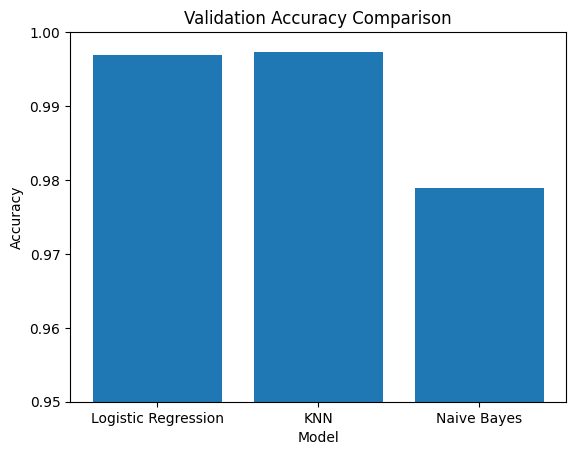

In [ ]:
models = list(results.keys())
accuracies = list(results.values())

plt.figure()
plt.bar(models, accuracies)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.95, 1.0)
plt.show()

In [ ]:
test_acc = knn.accuracy(X_test, y_test)
print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.9966903073286052


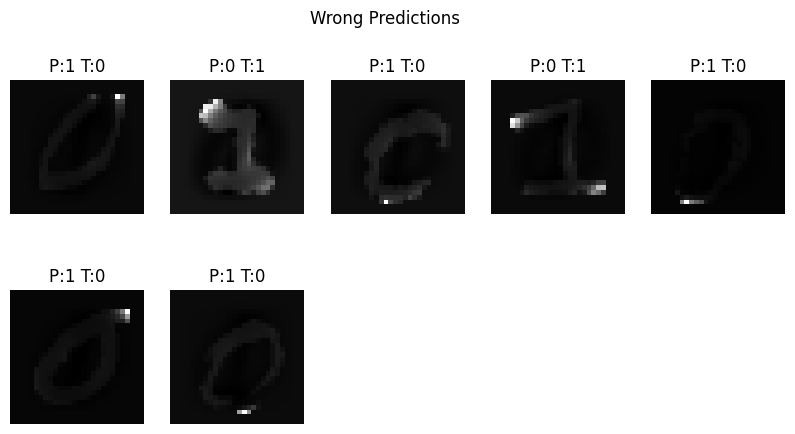

In [ ]:
wrong_indices = np.where(y_pred != y_test)[0]

plt.figure(figsize=(10,5))

for i, idx in enumerate(wrong_indices[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"P:{y_pred[idx]} T:{y_test[idx]}")
    plt.axis('off')

plt.suptitle("Wrong Predictions")
plt.show()

# Phase 2:Multiclass Classfification

In [4]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [5]:
# =========================
# 2) Normalize pixels to [0, 1]
# =========================
X_train = X_train.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32) / 255.0

# =========================
# 3) Flatten images
# =========================
X_train = X_train.reshape(X_train.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)

# =========================
# 4) Split TRAIN → train + validation
# =========================
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train   # keeps class balance
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

# =========================
# 5) Standardize (NO DATA LEAKAGE)
# =========================
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)

std[std == 0] = 1

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

Train shape: (51000, 784) (51000,)
Validation shape: (9000, 784) (9000,)
Test shape: (10000, 784) (10000,)


In [7]:
from NaiveBayes import NaiveBayes
nb = NaiveBayes()
nb.fit(X_train, y_train)

val_acc = nb.accuracy(X_val, y_val)
test_acc = nb.accuracy(X_test, y_test)

print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

Validation Accuracy: 0.5282222222222223
Test Accuracy: 0.5208


In [9]:
from KNN import KNN   # your implementation

# try a default value first
knn = KNN(k=5)

knn.fit(X_train, y_train)

val_acc = knn.accuracy(X_val, y_val)
train_acc = knn.accuracy(X_train, y_train)

print("Validation Accuracy:", val_acc)
print("Train Accuracy:", train_acc)



Validation Accuracy: 0.9447777777777778
Train Accuracy: 0.9633137254901961


In [5]:
from logistic_regression_ovr import LogisticRegressionOVR
# start SMALL (important)
model = LogisticRegressionOVR(learning_rate=0.01, epochs=200)

print("Training Logistic Regression (OvR)...")
model.fit(X_train, y_train)

print("Evaluating on validation...")
val_acc = model.accuracy(X_val, y_val)
print("Validation Accuracy:", val_acc)

Training Logistic Regression (OvR)...
Evaluating on validation...
Validation Accuracy: 0.8377777777777777


### Model Comparison: Naive Bayes vs Logistic Regression (OvR) vs KNN

| Aspect | Naive Bayes | Logistic Regression (OvR) | K-Nearest Neighbors (KNN) |
|-------|------------|----------------------------|---------------------------|
| Accuracy (Val) | ~52% | ~84% | ~94–95% |
| Model Type | Probabilistic (Generative) | Discriminative (Linear) | Instance-based (Non-parametric) |
| Assumptions | Strong feature independence | Linear decision boundary | No assumptions |
| Data Fit (MNIST) | Poor (pixels correlated) | Good (captures linear patterns) | Very good (captures similarity) |
| Training Speed | Very fast | Moderate | Very fast (just stores data) |
| Prediction Speed | Very fast | Fast | Very slow |
| Overfitting | Low | Moderate | Depends on k (low k → overfit) |
| Main Strength | Simplicity and speed | Balanced performance | Highest accuracy |
| Main Weakness | Unrealistic assumptions | Limited to linear boundaries | High computational cost |

### Explanation

- **Naive Bayes (~52%)**: Low accuracy due to unrealistic assumption that pixel features are independent, which does not hold for image data.
- **Logistic Regression (~84%)**: Significantly better as it learns feature weights and relationships, but is limited by linear decision boundaries.
- **KNN (~94–95%)**: Best performance because it directly compares images and captures similarity without assumptions, but at the cost of very high prediction time.

# Improvement 1
## Adding L2-Regularization for Logistc Regression Model


In [9]:
import importlib
import logistic_regression_ovr

importlib.reload(logistic_regression_ovr)
from logistic_regression_ovr import LogisticRegressionOVR

model = LogisticRegressionOVR(
    learning_rate=0.01,
    epochs=200,
    lambda_=0.1
)

model.fit(X_train, y_train)
val_acc = model.accuracy(X_val, y_val)

print("Validation Accuracy:", val_acc)

Validation Accuracy: 0.8377777777777777


In [10]:
train_acc = model.accuracy(X_train, y_train)
val_acc = model.accuracy(X_val, y_val)

print(train_acc, val_acc)

0.8409803921568627 0.8377777777777777


## Bias & variance analysis
training accuacy is > established_baseline (Naive Bayes),therefore we can conclude there is low bias
since training accuracy is almost equal dev accuracy  we can conlude there is low variance

# Improvement 2
## Ensemble models RFC

In [11]:
import importlib
import Ensemble

importlib.reload(Ensemble)
from Ensemble import RandomForest
rf = RandomForest(
    n_estimators=30,
    max_depth=10,
    min_samples_split=5
)

rf.fit(X_train, y_train)
train_acc = rf.accuracy(X_train, y_train)
val_acc = rf.accuracy(X_val, y_val)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

Train Accuracy: 0.9528039215686275
Validation Accuracy: 0.9317777777777778


# Improvement 3 
## hyperparameter tuning

In [8]:
import Utilities
lambda_values = [0.0, 0.01, 0.1, 1.0]

Utilities.Utilities.tune_logistic_lambda(X_train, y_train, X_val, y_val, lambda_values)

lambda=0.0, Val Acc=0.8378
lambda=0.01, Val Acc=0.8378
lambda=0.1, Val Acc=0.8378


KeyboardInterrupt: 

## Note
as observed above our LR model is not overfitting thus changing lambda wont change much 
as seen in first 3 values of lamda which took very large amount to validate 
36 mins so i will stop here
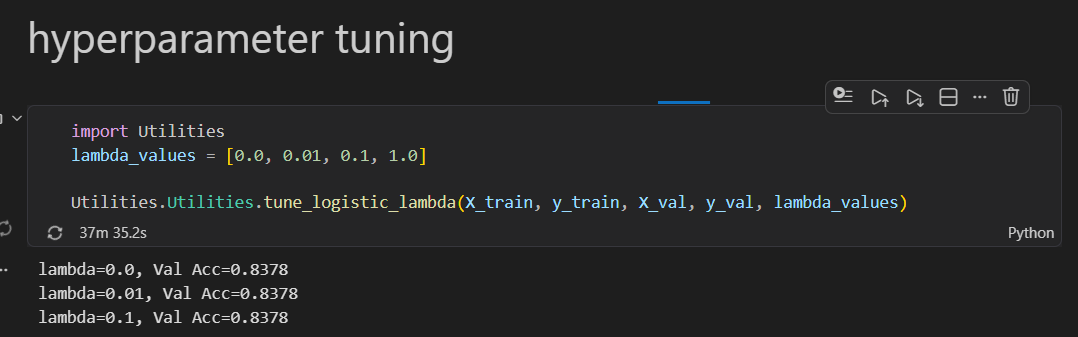


## Note 
I wont tune KNN as it will take hours 

In [15]:
import importlib
import Utilities

importlib.reload(Utilities)
configs = [
    (20, 10, 5),
    (30, 10, 5),
    (30, 8, 5),
    (50, 10, 10),
]

Utilities.Utilities.tune_random_forest(
    X_train, y_train,
    X_val, y_val,
    configs
)

n=20, depth=10, min_split=5 | Train=0.9507 | Val=0.9304
n=30, depth=10, min_split=5 | Train=0.9541 | Val=0.9321
n=30, depth=8, min_split=5 | Train=0.9170 | Val=0.9106
n=50, depth=10, min_split=10 | Train=0.9558 | Val=0.9406


[(20, 10, 5, np.float64(0.9507450980392157), np.float64(0.9304444444444444)),
 (30, 10, 5, np.float64(0.9541372549019608), np.float64(0.9321111111111111)),
 (30, 8, 5, np.float64(0.9170392156862746), np.float64(0.9105555555555556)),
 (50, 10, 10, np.float64(0.9558235294117647), np.float64(0.9405555555555556))]

The best Random Forest configuration (50 trees, depth=10, min_samples_split=10) achieved the highest validation accuracy (~94.1%) with good generalization, showing that increasing tree count and controlling split size improves performance.

## Test set Final evaluation

In [16]:
rf = RandomForest(
    n_estimators=50,
    max_depth=10,
    min_samples_split=10
)

rf.fit(X_train, y_train)

test_acc = rf.accuracy(X_test, y_test)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.9419


# Deployment

In [17]:
X_full = np.concatenate((X_train, X_val))
y_full = np.concatenate((y_train, y_val))

rf = RandomForest(
    n_estimators=50,
    max_depth=10,
    min_samples_split=10
)

rf.fit(X_full, y_full)

In [20]:
import pickle

with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [23]:
np.save("mean.npy", mean)
np.save("std.npy", std)